# Molmo2 + SAM2 → 3D affordance grounding — step-by-step (Mug)

Take ONE object (Mug) + ONE bimanual task from the stage-1 v13.2 dataset (outputs/stage1_v2/), and verify the
**production stage2_v2 chain** (`pipeline/stage2_v2.py`) step by step:

1. **canvas = affogato's raw point cloud** for this object (`xyzc.npy`) — we do NOT rebuild a cloud by
   back-projecting depth; we vote onto the existing affogato points,
2. **Molmo2-8B on vLLM** points to each role's contact region — k=4 multi-image prompts, both roles in
   ONE `llm.generate` (exactly what the runner does per object),
3. **SAM2** turns each point into a per-view mask/heatmap (object-batched: encoder once per object;
   "mixed+neg" prompts: body targets -> smallest candidate, named parts -> best_iou, partner point
   as negative beyond 30px),
4. multi-view **voting** maps the per-view heatmaps back onto the affogato canvas points
   (projection geometry precomputed once per object),
4b. canvas **refinement** (satellite-component prune + kNN smoothing), **partition v6**
   (text symmetry -> center cut / text vertical -> gravity cut / evidence split, overlap fully
   resolved) and a guarded **post-prune** produce the final disjoint role heatmaps,
5. visualize the two coordinated hand regions (role A + role B) on the object, and compare against the
   affogato GT affordance channels.

Same modules as the runner: `single_region/molmo2_vllm/engine.py` (pointing) +
`single_region/single_region_affordance.py` (SAM2/voting/partition).
Run with the **molmo** kernel (`Python (molmo)`: vllm 0.16 + torch cu128 + SAM2).

## 0 · Setup (env, GPU, imports)
Pin a free GPU (here GPU 3) before importing torch — `CUDA_VISIBLE_DEVICES` only takes effect
if set before the first torch import.

In [1]:
import os, sys
os.environ["CUDA_VISIBLE_DEVICES"] = "3"          # free GPU; Molmo-8B + SAM2 fit
os.environ["CUDA_DEVICE_ORDER"]   = "PCI_BUS_ID"  # match nvidia-smi ordering
os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"      # needed before cv2 reads the depth EXR

DG = "/home/michaellee/mclee/affogato/data_generation"
sys.path.insert(0, DG)
os.chdir(DG)   # so PipelineConfig's relative checkpoints/ + configs/ paths resolve

import numpy as np, json, cv2
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import torch
import single_region.single_region_affordance as sra   # validated geometry/Molmo/SAM2/voting fns

print("torch", torch.__version__, "| cuda", torch.cuda.is_available(),
      "| device", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

torch 2.9.1+cu128 | cuda True | device NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition


## 1 · Pick the object, load its bimanual task + the affogato canvas
The stage-1 `object_id` is the affogato/objaverse UID. `daily_used_to_affogato.json` maps the
gObjaverse render folder (`src`) ↔ the affogato dir (`dst`, holding `xyzc.npy` + `queries.json`).

In [2]:
OBJ_ID = "849b4573e03a40b8b073a2209d1bc1d3"   # Mug

# stage-1 record (our bimanual tasks + per-role molmo_queries)
rec = next(o for o in json.load(open(f"{DG}/outputs/stage1_v2/stage1_part0.json"))
           if o["object_id"] == OBJ_ID)
OBJ_ROOT = "/".join(rec["views_used"][0].split("/")[:-2])   # gObjaverse render folder

# affogato canvas dir (dst) via the mapping
mp = json.load(open(f"{DG}/dataset/daily_used_to_affogato.json"))
AFF = next(e["dst"] for e in mp if e["object_id"] == OBJ_ID)

print("OBJECT  :", rec["object_name"], "| components:", [c["name"] for c in rec["components"]])
print("renders :", OBJ_ROOT)
print("affogato:", AFF)
for i, q in enumerate(rec["queries"]):
    print(f"  [{i}] ({q['category']}) {q['task']}")

# --- choose the task to ground (0 = 'pick up the Mug': lift @ handle + hold @ body) ---
QUERY_IDX = 0
query = rec["queries"][QUERY_IDX]
print("\nGrounding task:", query["task"])
for r, mq in zip(query["roles"], query["molmo_queries"]):
    print(f"  hand {r['id']}: {r['role']:6s} {r['target']:6s} @ {r['contact_region']}")
    print(f"           molmo_query: {mq}")

OBJECT  : Mug | components: ['body', 'handle', 'rim', 'base']
renders : /nfs_drive/gobjaverse/daily-used/52/272590
affogato: /home/michaellee/mclee/affogato/dataset/affogato/affogato_all_part004/849b4573e03a40b8b073a2209d1bc1d3
  [0] (inter) pick up the Mug
  [1] (pose) tilt the mug for pouring
  [2] (pose) level the mug for drinking

Grounding task: pick up the Mug
  hand A: lift   handle @ the middle of the handle
           molmo_query: Point to the middle of the handle where a robot hand should lift it to actuate the primary lift.
  hand B: hold   body   @ the mid-height of the side wall opposite the handle
           molmo_query: Point to the mid-height of the side wall opposite the handle where a robot hand should hold it to steady the mug during the lift.


## 2 · Load the affogato canvas + camera params
`xyzc.npy` = [N,3] xyz + [N,K] GT affordance channels. The affogato points use a different axis
convention than the gObjaverse cameras, so we align them once (**swap Y/Z, flip new Y** — exactly
`sra.align_affogato_frame`) to get `xyz_vote`; `gt[i]` stays attached to point `i`. Camera
extrinsics / intrinsics / render-depth come from the gObjaverse views (for the visibility test).

In [3]:
xyzc = np.load(f"{AFF}/xyzc.npy").astype(np.float32)
xyz, gt = xyzc[:, :3], xyzc[:, 3:]                       # canvas points + GT affordance channels
gt_meta = json.load(open(f"{AFF}/queries.json"))[0]
gt_queries = gt_meta["queries"]
print("canvas:", xyz.shape, "| GT channels:", gt.shape[1], "| class:", gt_meta.get("class_name"))

# align affogato frame -> gObjaverse camera frame (required before projecting/voting)
xyz_vote = xyz[:, [0, 2, 1]].copy(); xyz_vote[:, 1] *= -1

NUM_VIEWS = min(sra.count_available_views(OBJ_ROOT), 40)
view_images, view_images_np = sra.load_view_images(OBJ_ROOT, NUM_VIEWS)
cameras, K_list, depth_maps = sra.prepare_camera_params(OBJ_ROOT, NUM_VIEWS)   # (c2w, w2c=inv(c2w_conv)), K, depth
print(f"using {NUM_VIEWS} views for voting")

canvas: (16384, 3) | GT channels: 5 | class: Mug


Preparing camera matrices: 100%|██████████| 40/40 [00:00<00:00, 67.52it/s]

using 40 views for voting


**Verify the canvas** — the affogato point cloud should look like the Mug.

In [4]:
def show_cloud(xyz, color, title, cmin=None, cmax=None, colorscale=None, colorbar=False, size=1.0):
    s = slice(None, None, max(1, len(xyz)//60000))
    marker = dict(size=size, opacity=0.85)
    if colorscale is None:
        marker["color"] = color                          # fixed color string or rgb array
    else:
        marker.update(color=color[s], colorscale=colorscale, cmin=cmin, cmax=cmax,
                      colorbar=(dict(title="score") if colorbar else None))
    fig = go.Figure(go.Scatter3d(x=xyz[s,0], y=xyz[s,1], z=xyz[s,2], mode="markers", marker=marker))
    fig.update_layout(title=title, width=820, height=620,
                      scene=dict(aspectmode="data"), margin=dict(l=0,r=0,t=30,b=0))
    return fig

show_cloud(xyz, "lightslategrey", f"{rec['object_name']} — affogato canvas ({len(xyz):,} pts)").show()

## 3 · Load the vLLM pointing engine + SAM2
`m2v.load_engine` starts Molmo2-8B on vLLM (≈2 min: weights + CUDA graphs; reserves
`gpu_memory_utilization`×GPU for weights+KV). Engine FIRST, SAM2 second — vLLM profiles free GPU
memory at startup (same order as the runner).

In [5]:
from single_region.molmo2_vllm import engine as m2v

llm, proc = m2v.load_engine(gpu_memory_utilization=0.5)   # Molmo2-8B on vLLM (engine BEFORE SAM2)

cfg = sra.PipelineConfig(num_views=NUM_VIEWS)     # defaults: best_iou mask fallback, depth_tol=0.15
sam2_predictor = sra.load_sam2_model(cfg.sam2_checkpoint, cfg.sam2_model_cfg, cfg.device)
print("loaded:", m2v.MODEL_ID, "+", os.path.basename(cfg.sam2_checkpoint))

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


INFO 07-11 14:45:55 [utils.py:223] non-default args: {'trust_remote_code': True, 'max_model_len': 8192, 'gpu_memory_utilization': 0.5, 'disable_log_stats': True, 'limit_mm_per_prompt': {'image': 4, 'video': 0}, 'mm_encoder_attn_backend': 'TORCH_SDPA', 'model': 'allenai/Molmo2-8B'}


The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


INFO 07-11 14:45:57 [model.py:529] Resolved architecture: Molmo2ForConditionalGeneration
INFO 07-11 14:45:57 [model.py:1871] Downcasting torch.float32 to torch.bfloat16.
INFO 07-11 14:45:57 [model.py:1549] Using max model len 8192
INFO 07-11 14:45:57 [scheduler.py:224] Chunked prefill is enabled with max_num_batched_tokens=16384.
INFO 07-11 14:45:57 [vllm.py:689] Asynchronous scheduling is enabled.
WARNING 07-11 14:45:57 [cuda.py:260] Forcing --disable_chunked_mm_input for models with multimodal-bidirectional attention.
(EngineCore_DP0 pid=3470687) INFO 07-11 14:46:25 [core.py:97] Initializing a V1 LLM engine (v0.16.0) with config: model='allenai/Molmo2-8B', speculative_config=None, tokenizer='allenai/Molmo2-8B', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.bfloat16, max_seq_len=8192, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, disable_custom_a

(EngineCore_DP0 pid=3470687) Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


...

(EngineCore_DP0 pid=3470687) INFO 07-11 14:46:57 [default_loader.py:293] Loading weights took 10.64 seconds
(EngineCore_DP0 pid=3470687) INFO 07-11 14:46:58 [gpu_model_runner.py:4221] Model loading took 16.15 GiB memory and 12.431322 seconds
(EngineCore_DP0 pid=3470687) INFO 07-11 14:46:58 [gpu_model_runner.py:5140] Encoder cache will be initialized with a budget of 16384 tokens, and profiled with 11 image items of the maximum feature size.
(EngineCore_DP0 pid=3470687) INFO 07-11 14:47:10 [backends.py:916] Using cache directory: /home/michaellee/.cache/vllm/torch_compile_cache/497891bcbb/rank_0_0/backbone for vLLM's torch.compile
(EngineCore_DP0 pid=3470687) INFO 07-11 14:47:10 [backends.py:976] Dynamo bytecode transform time: 8.62 s
(EngineCore_DP0 pid=3470687) INFO 07-11 14:47:18 [backends.py:267] Directly load the compiled graph(s) for compile range (1, 16384) from the cache, took 1.887 s
(EngineCore_DP0 pid=3470687) INFO 07-11 14:47:18 [monitor.py:34] torch.compile takes 10.51 s in

Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 51/51 [00:03<00:00, 14.33it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 51/51 [00:03<00:00, 14.50it/s]


(EngineCore_DP0 pid=3470687) INFO 07-11 14:47:27 [gpu_model_runner.py:5246] Graph capturing finished in 8 secs, took 0.73 GiB
(EngineCore_DP0 pid=3470687) INFO 07-11 14:47:27 [core.py:278] init engine (profile, create kv cache, warmup model) took 28.95 seconds
(EngineCore_DP0 pid=3470687) INFO 07-11 14:47:28 [vllm.py:689] Asynchronous scheduling is enabled.
INFO 07-11 14:47:28 [llm.py:355] Supported tasks: ['generate']
Loading SAM2: checkpoints/sam2.1_hiera_large.pt ...


[2026-07-11 14:47:31] INFO build_sam.py:174: Loaded checkpoint sucessfully


loaded: allenai/Molmo2-8B + sam2.1_hiera_large.pt


## 4 · Ground the task — the runner's per-object flow
Both roles' `"Point to ..."` queries go into **ONE `llm.generate`** as k=4 multi-image chunks
(official `"Point to {label} in all images."` template); SAM2 embeds the 40 views **once** and
decodes each role's masks; voting samples the heatmaps through the **precomputed** projection.
This mirrors `stage2_v2`'s per-object flow (SAM prompts via the runner's own
`build_sam_prompts`); §5.5 then applies the same refine -> partition -> post-prune the runner
saves. The intermediates (`ptsA/B`, `hmA/B`, `scoreA/B`, `refA/B`) are kept for inspection. Voting uses the **aligned**
`xyz_vote`, so `scores[i]` corresponds to canvas point `xyz[i]`.

In [ ]:
# --- the chosen task's two roles ---
roleA = query["roles"][0]; mqA = query["molmo_queries"][0]
roleB = query["roles"][1]; mqB = query["molmo_queries"][1]
print("role A:", mqA); print("role B:", mqB)

# 1) pointing: BOTH roles in one llm.generate (k=4 multi-image chunks, continuous batching)
per_query, n_oob = m2v.ground_queries(llm, proc, view_images, [mqA, mqB], k=4)
ptsA = [[np.array(p, dtype=np.float32)] if p is not None else [] for p in per_query[0]]
ptsB = [[np.array(p, dtype=np.float32)] if p is not None else [] for p in per_query[1]]
print(f"Molmo2 hits: A {sum(map(len, ptsA))}/{NUM_VIEWS}  B {sum(map(len, ptsB))}/{NUM_VIEWS}"
      + (f"  (oob {n_oob})" if n_oob else ""))

# 2) SAM2 object-batched: encoder once; production "mixed+neg" prompts —
#    body-level target -> smallest candidate, named part -> best_iou; partner
#    point as negative when >30px (the runner's build_sam_prompts, reused)
from pipeline.stage2_v2 import build_sam_prompts
mask_selects, neg_points = build_sam_prompts([(0, query)], per_query)
hmA, hmB = sra.run_sam2_object_queries(view_images_np, [ptsA, ptsB], sam2_predictor, cfg,
                                       neg_points=neg_points, mask_selects=mask_selects)
print("mask_selects:", mask_selects)

# 3) voting with the per-object projection cache
proj = sra.precompute_projection(xyz_vote, cameras, K_list, depth_maps, cfg.depth_tolerance)
scoreA, counts = sra.sample_heatmaps_projected(proj, hmA)
scoreB, _      = sra.sample_heatmaps_projected(proj, hmB)
print(f"coverage {(counts > 0).mean()*100:.0f}% | scoreA mean {scoreA.mean():.3f} | scoreB mean {scoreB.mean():.3f}")

**Verify Molmo** — each role's predicted point should land on its contact_region in every view (role A, then role B).

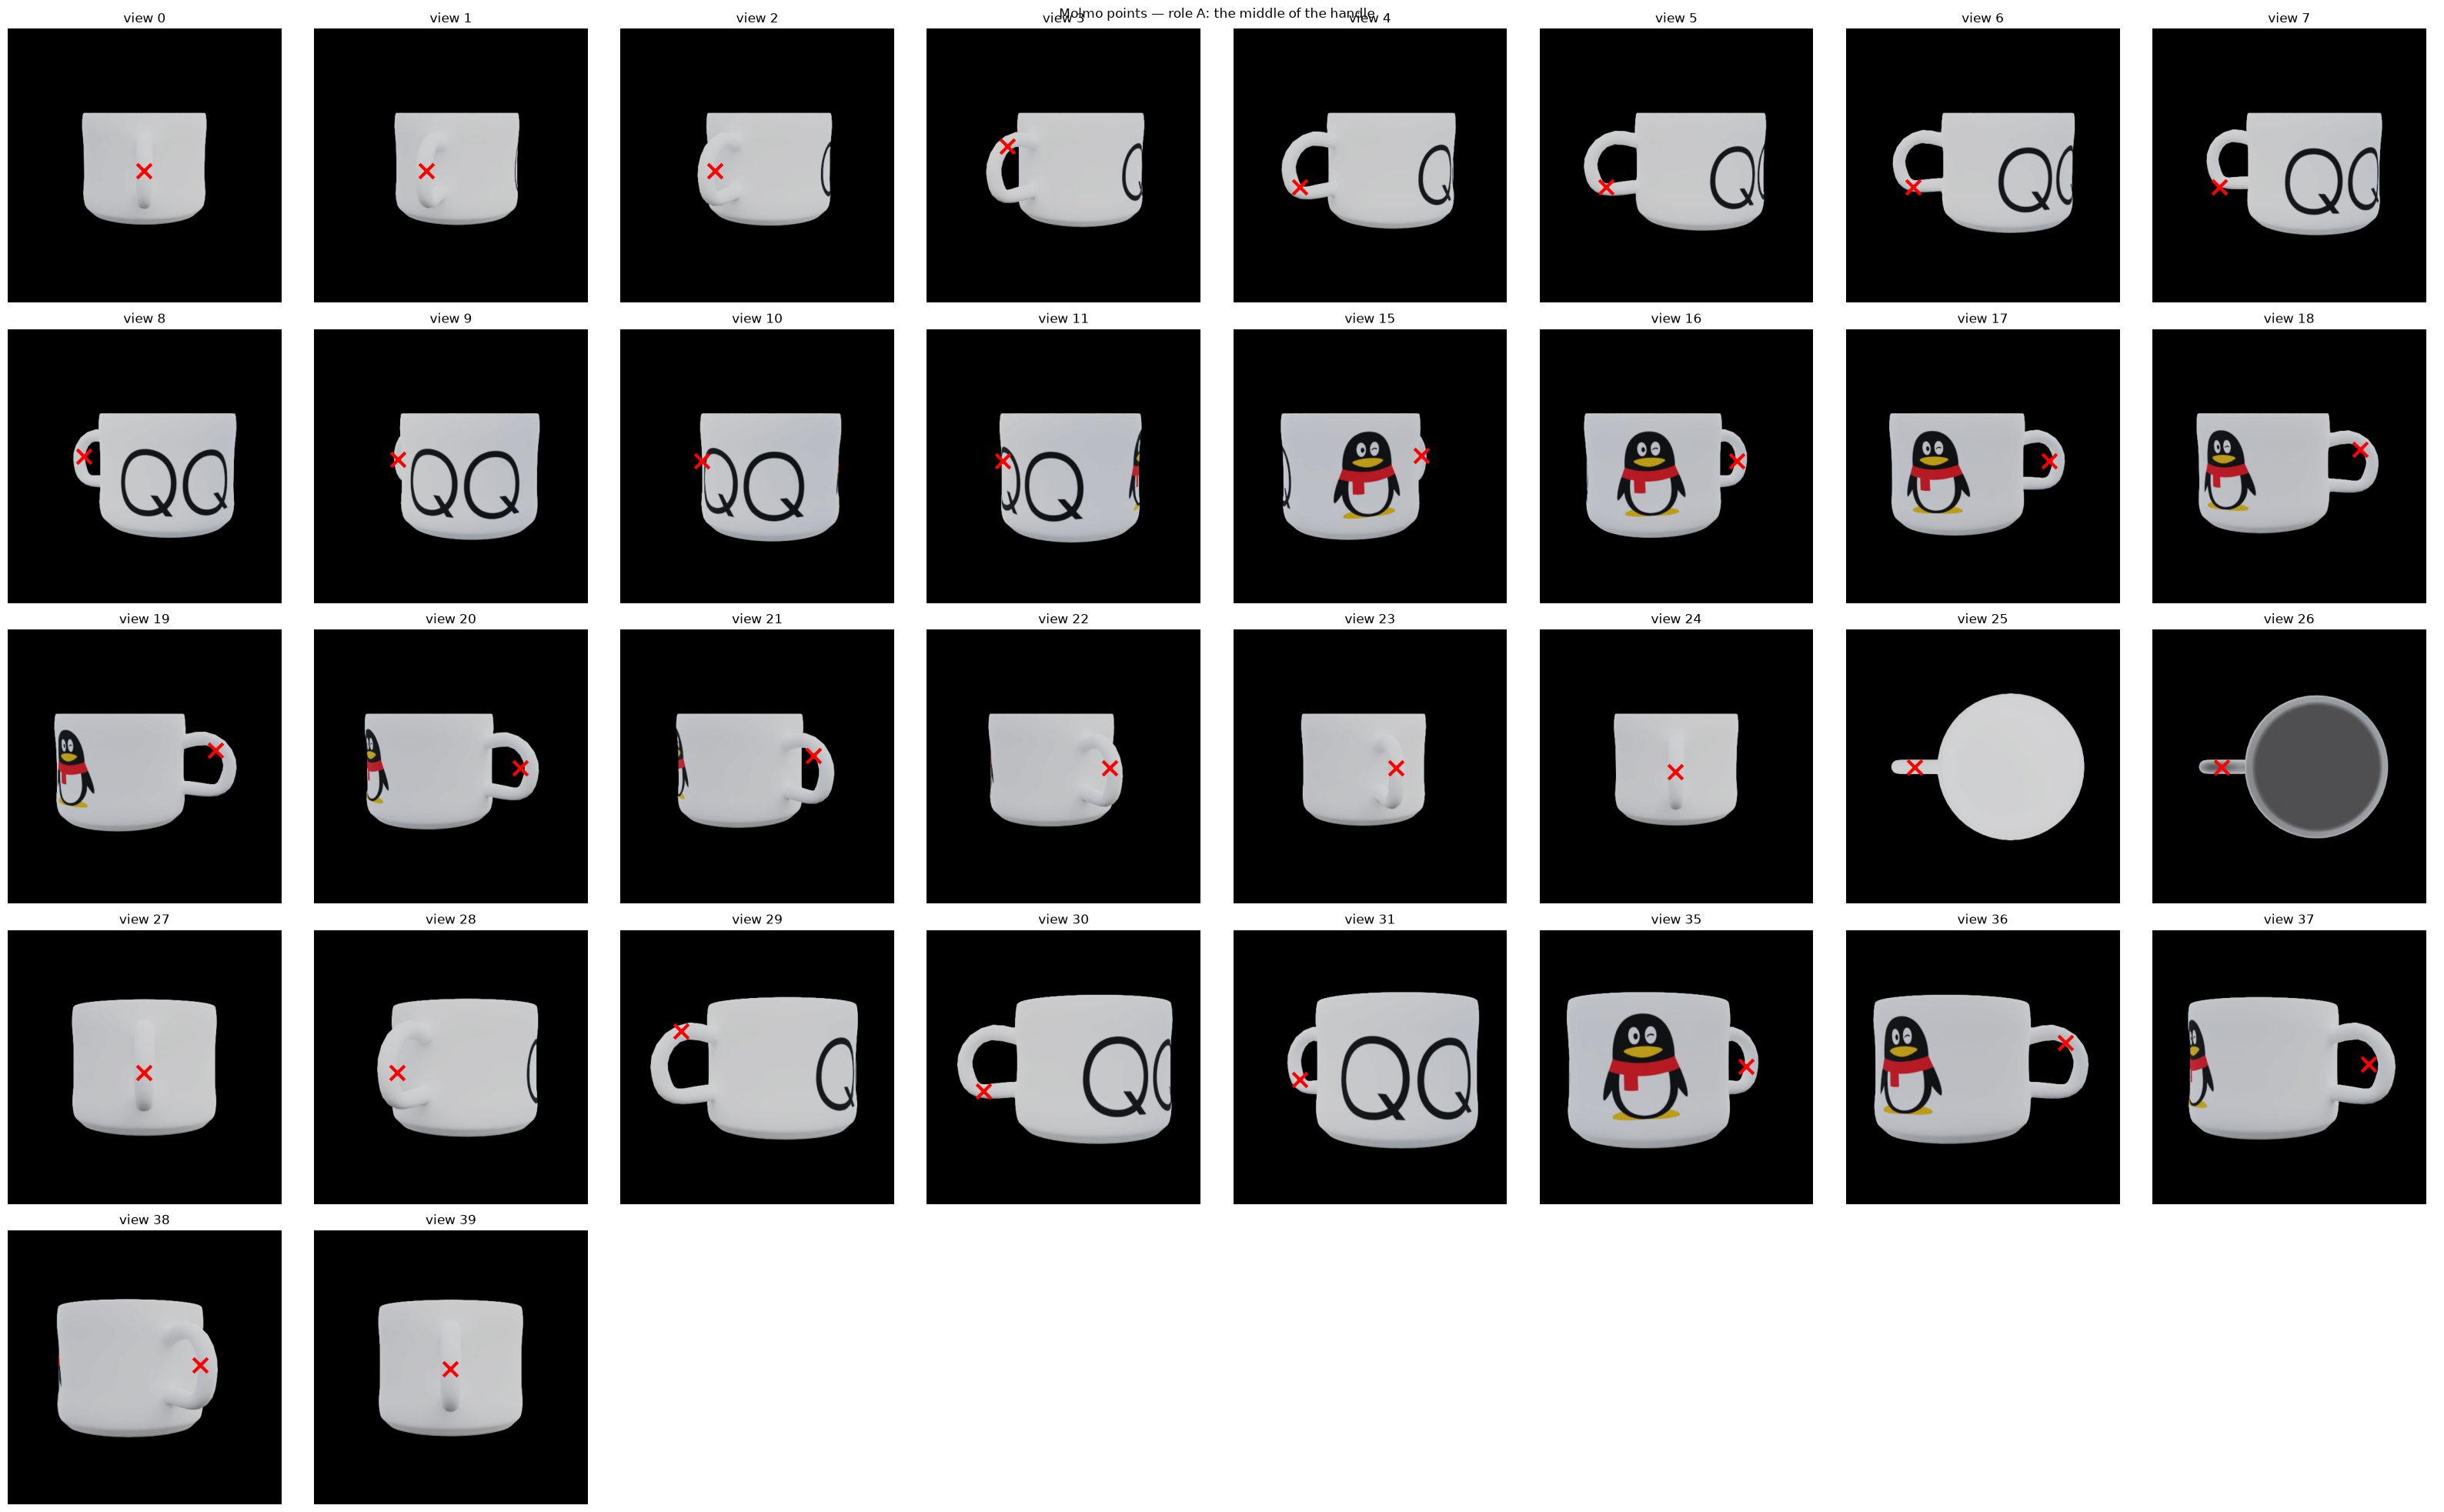

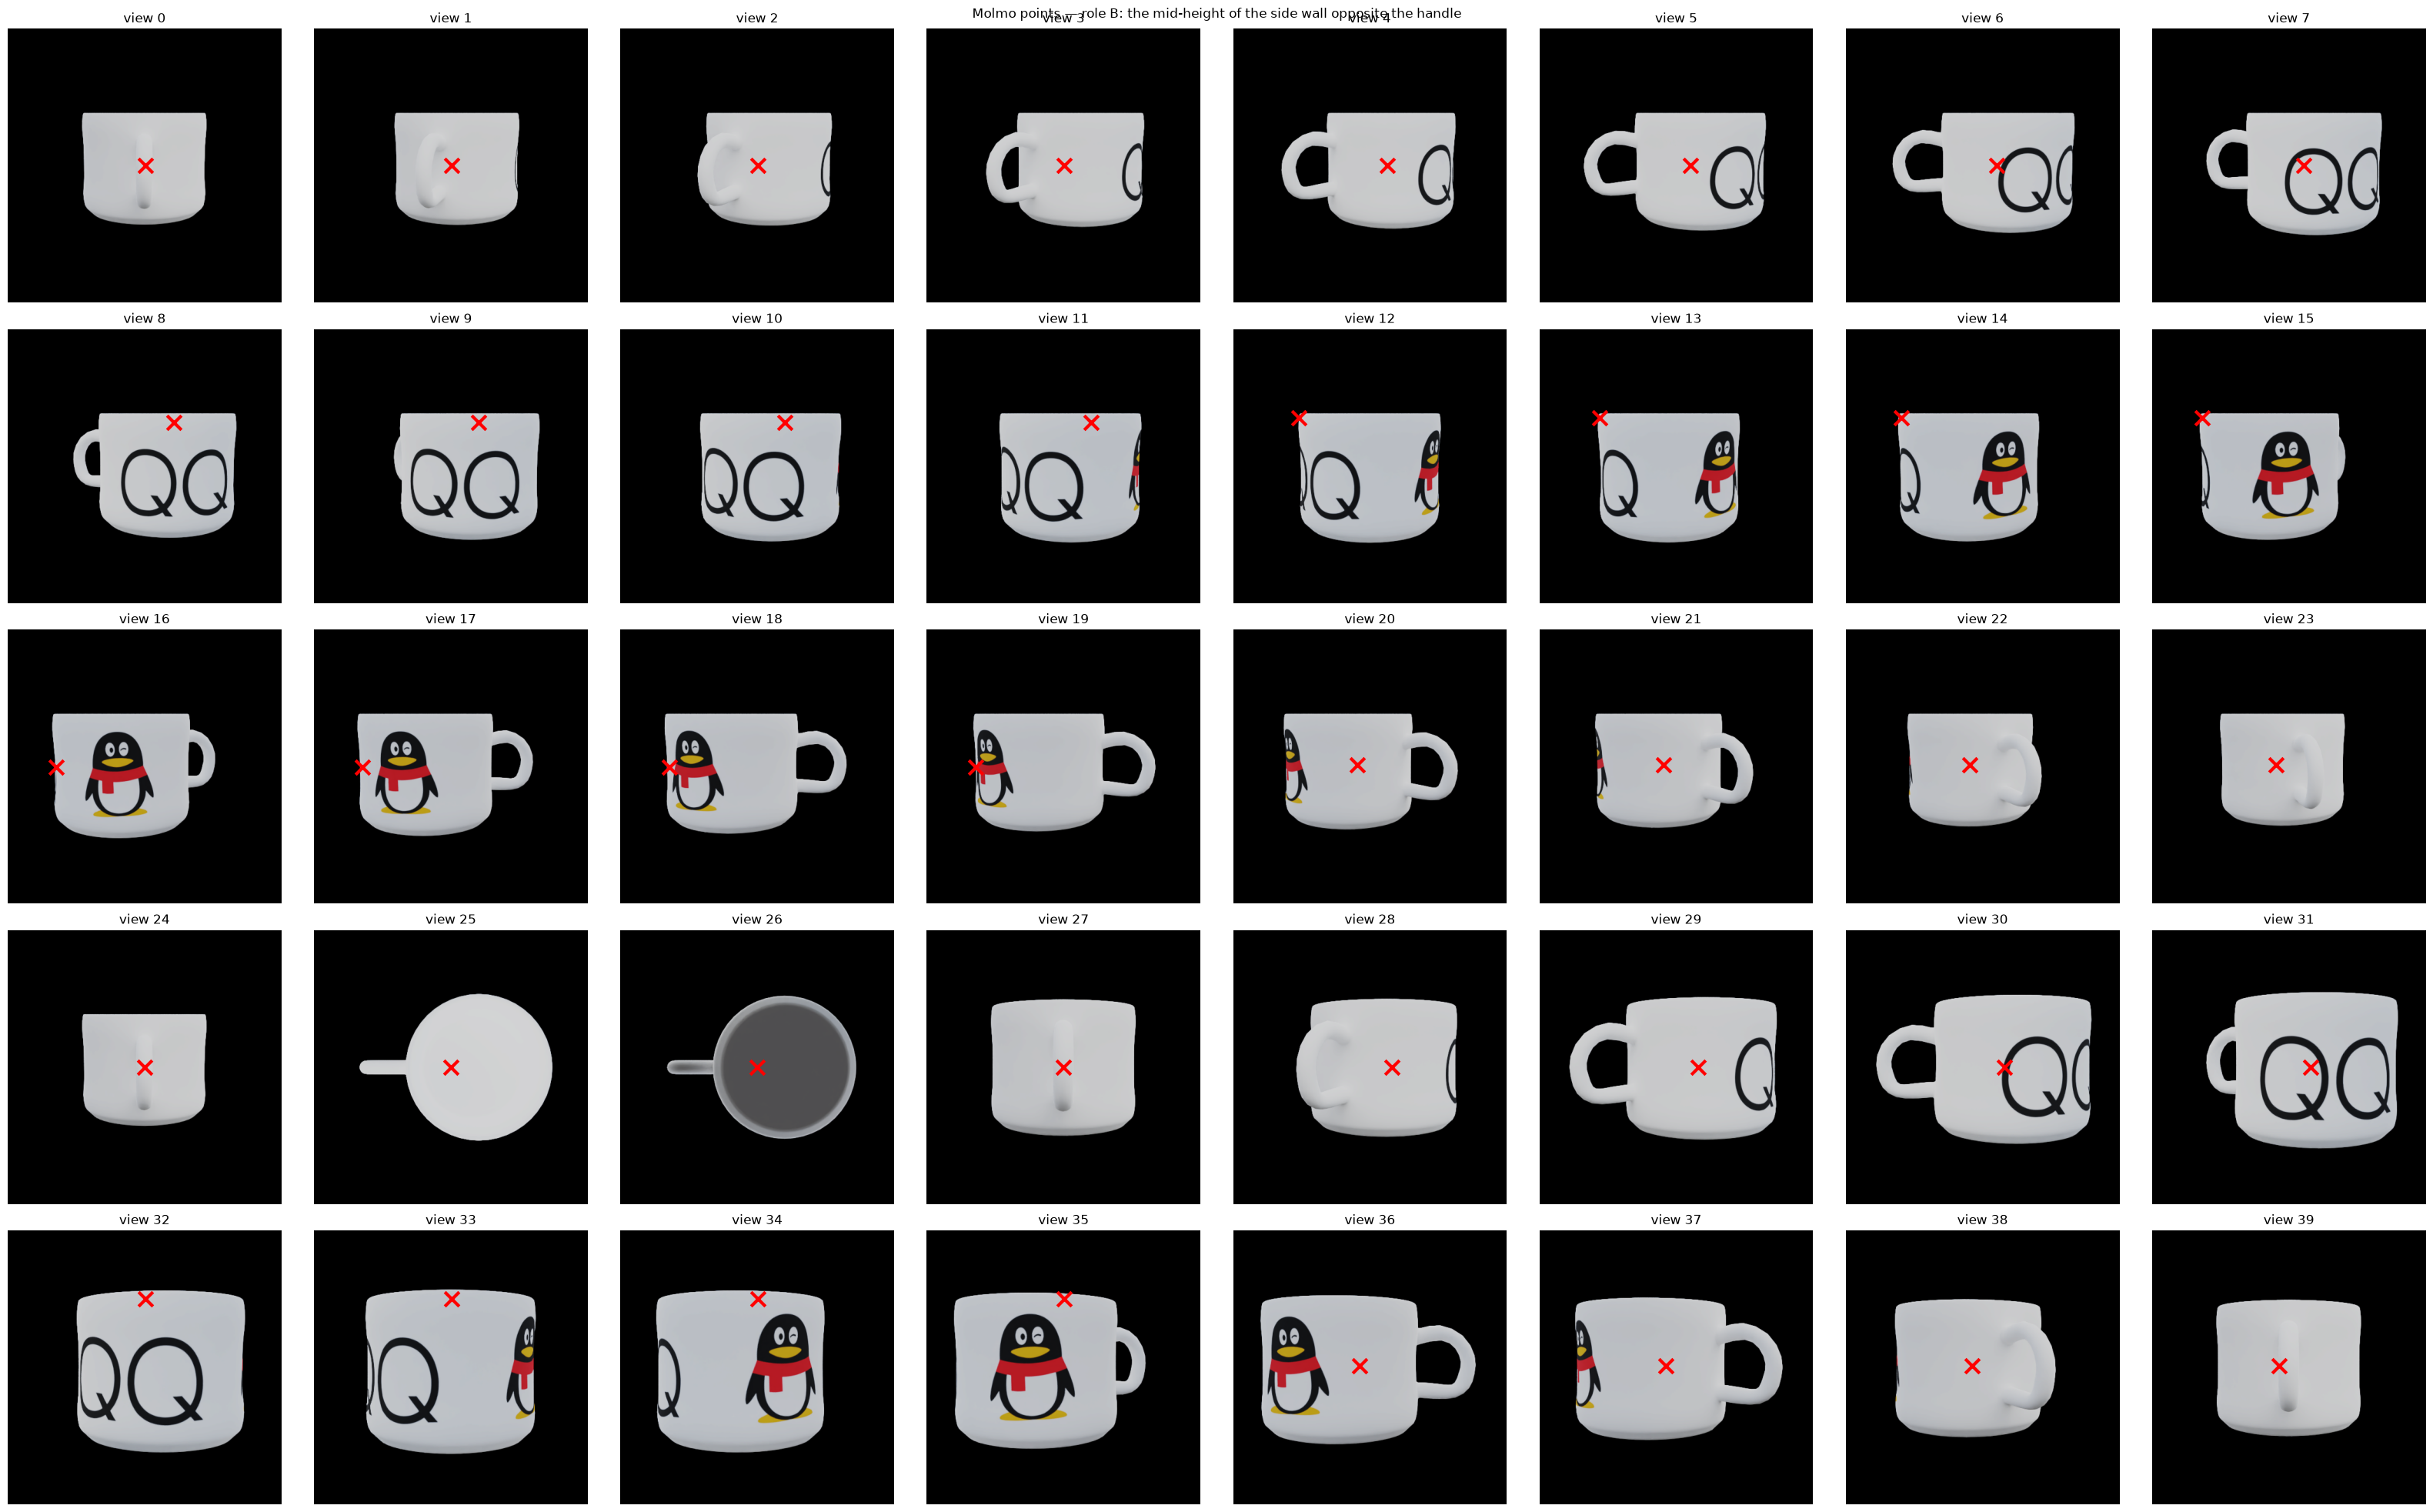

In [7]:
def show_points_on_views(pts_per_view, title, n=6):
    have = [i for i, p in enumerate(pts_per_view) if len(p) > 0][:n]
    if not have: print("no Molmo points to show"); return
    cols = min(8, len(have)); rows = (len(have)+cols-1)//cols
    fig, ax = plt.subplots(rows, cols, figsize=(4*cols, 4*rows)); ax = np.atleast_1d(ax).ravel()
    for k, vi in enumerate(have):
        ax[k].imshow(view_images_np[vi])
        for (x, y) in pts_per_view[vi]:
            ax[k].scatter([x], [y], s=180, marker="x", c="red", linewidths=3)
        ax[k].set_title(f"view {vi}"); ax[k].axis("off")
    for k in range(len(have), len(ax)): ax[k].axis("off")
    fig.suptitle(title); plt.tight_layout(); plt.show()

show_points_on_views(ptsA, f"Molmo points — role A: {roleA['contact_region']}", n=NUM_VIEWS)
show_points_on_views(ptsB, f"Molmo points — role B: {roleB['contact_region']}", n=NUM_VIEWS)

**Verify SAM2** — each Molmo point should expand to a mask covering that region.

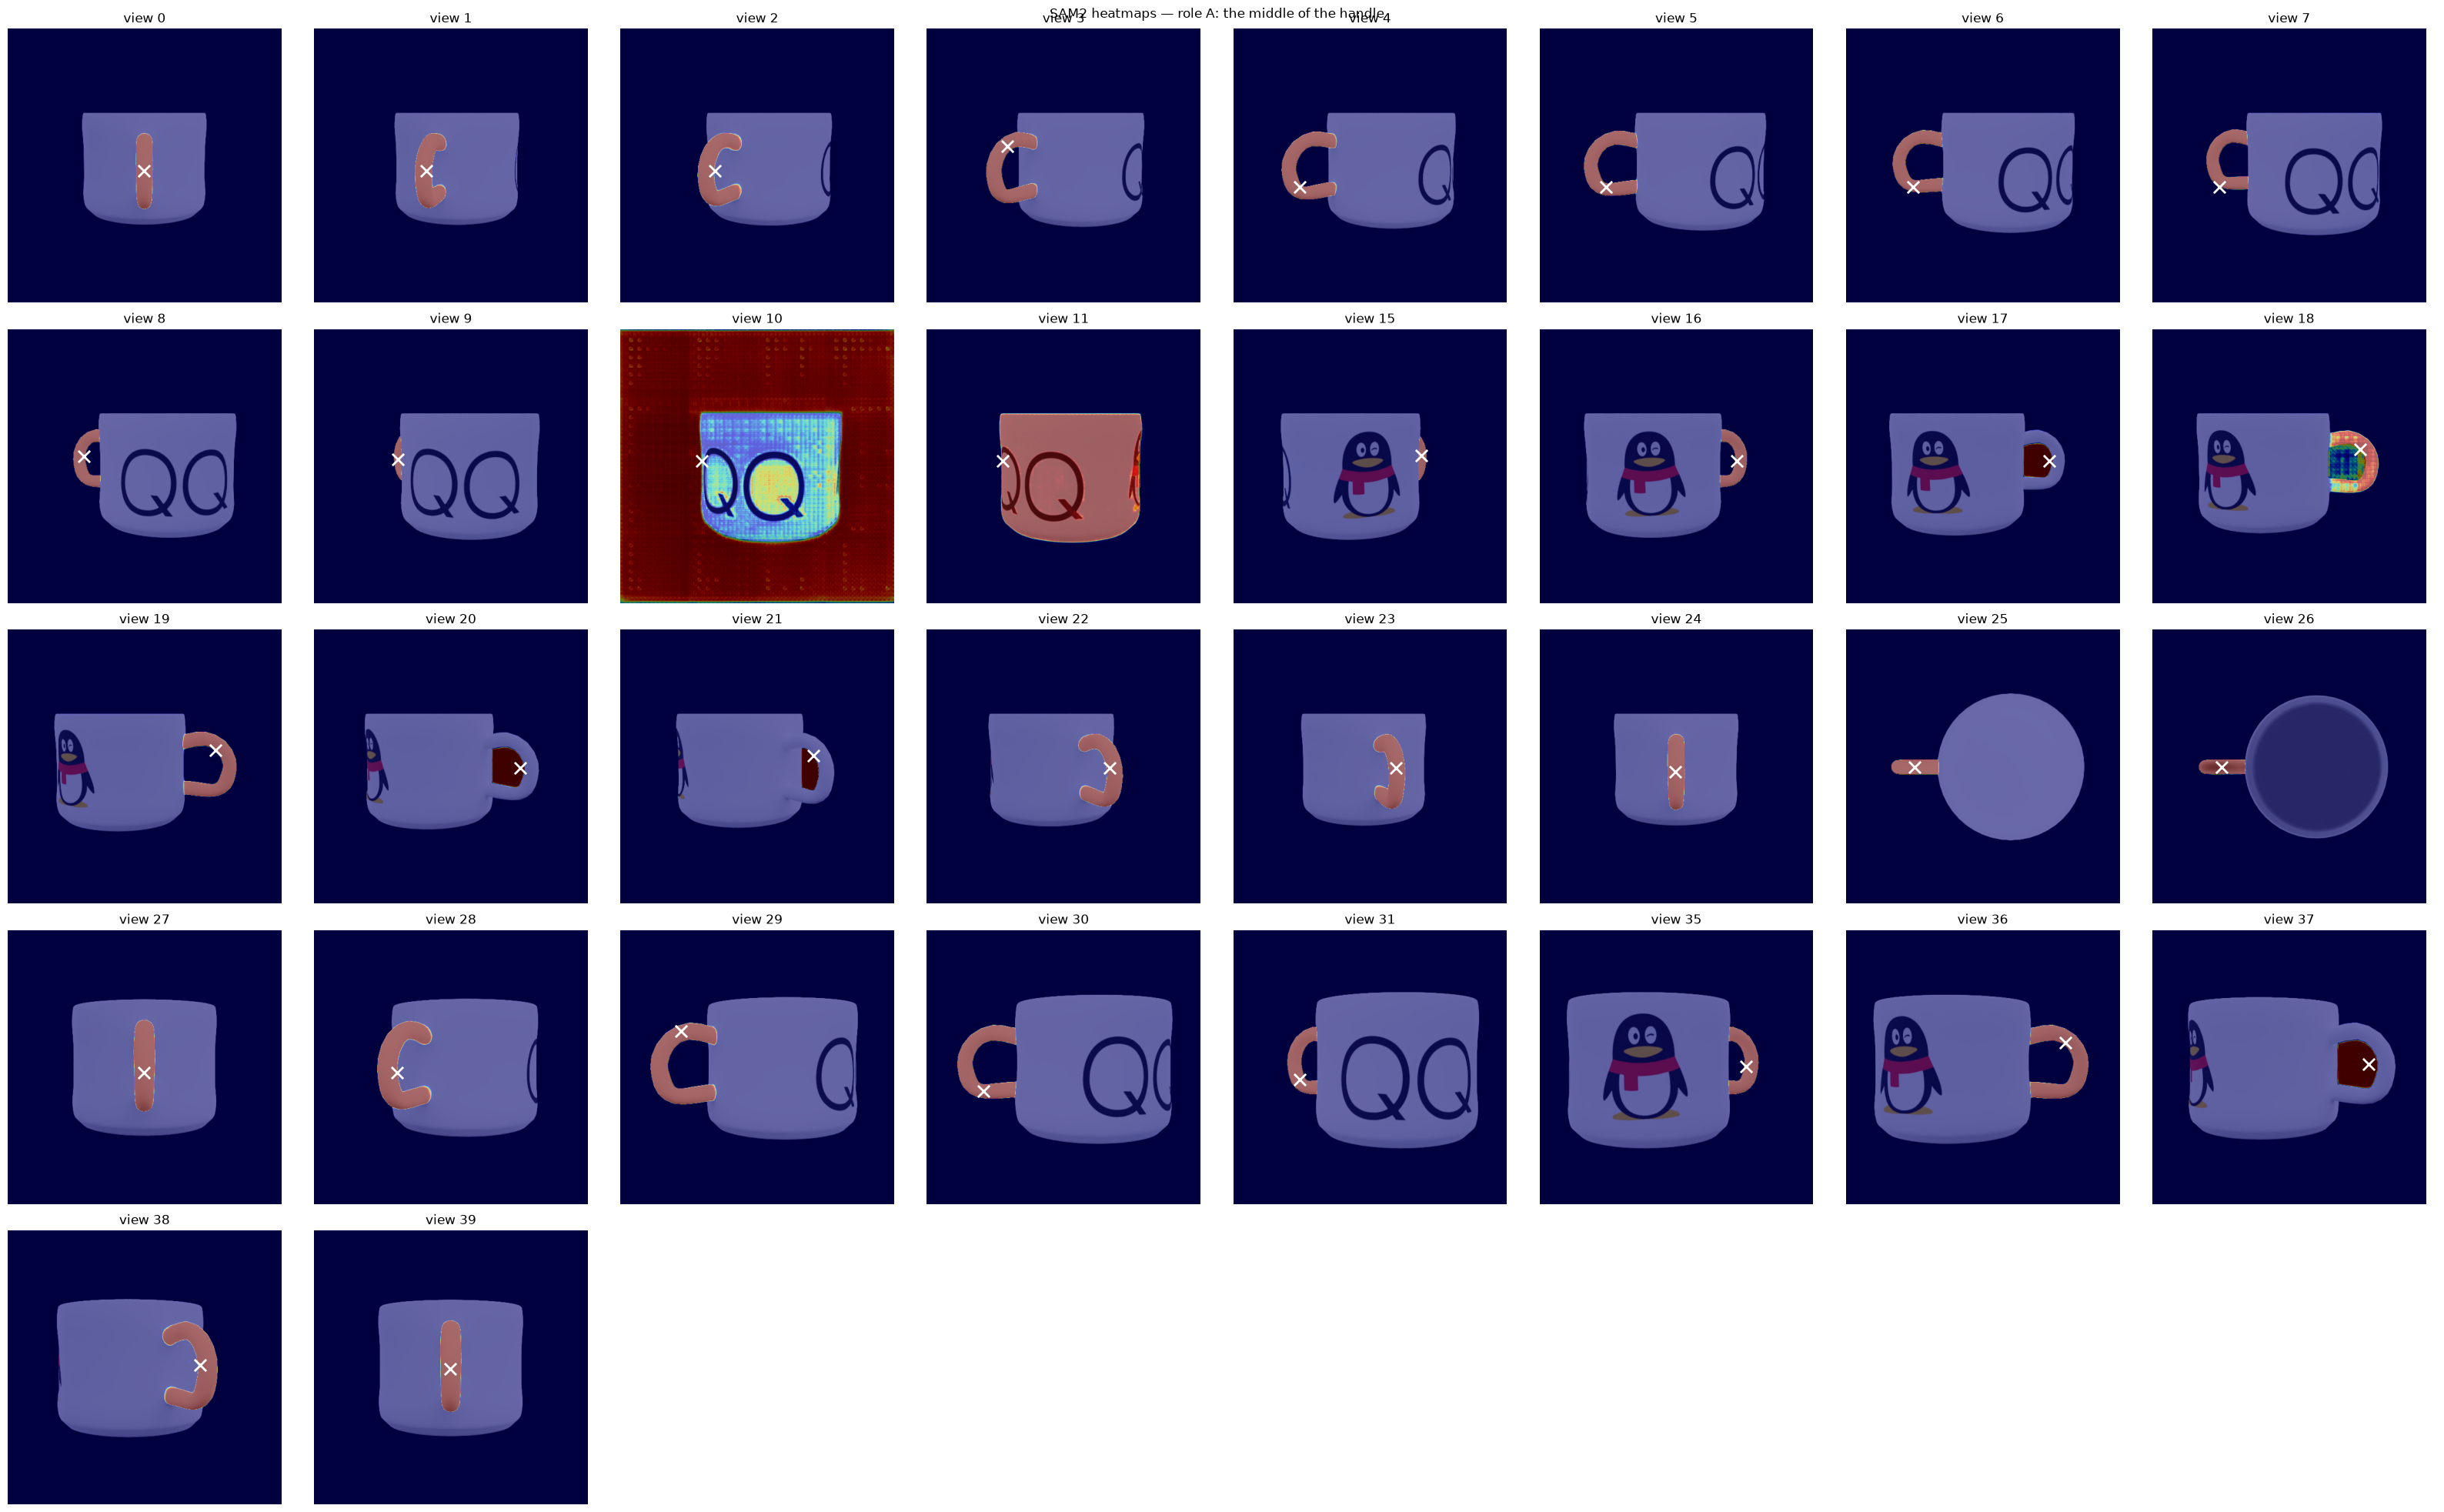

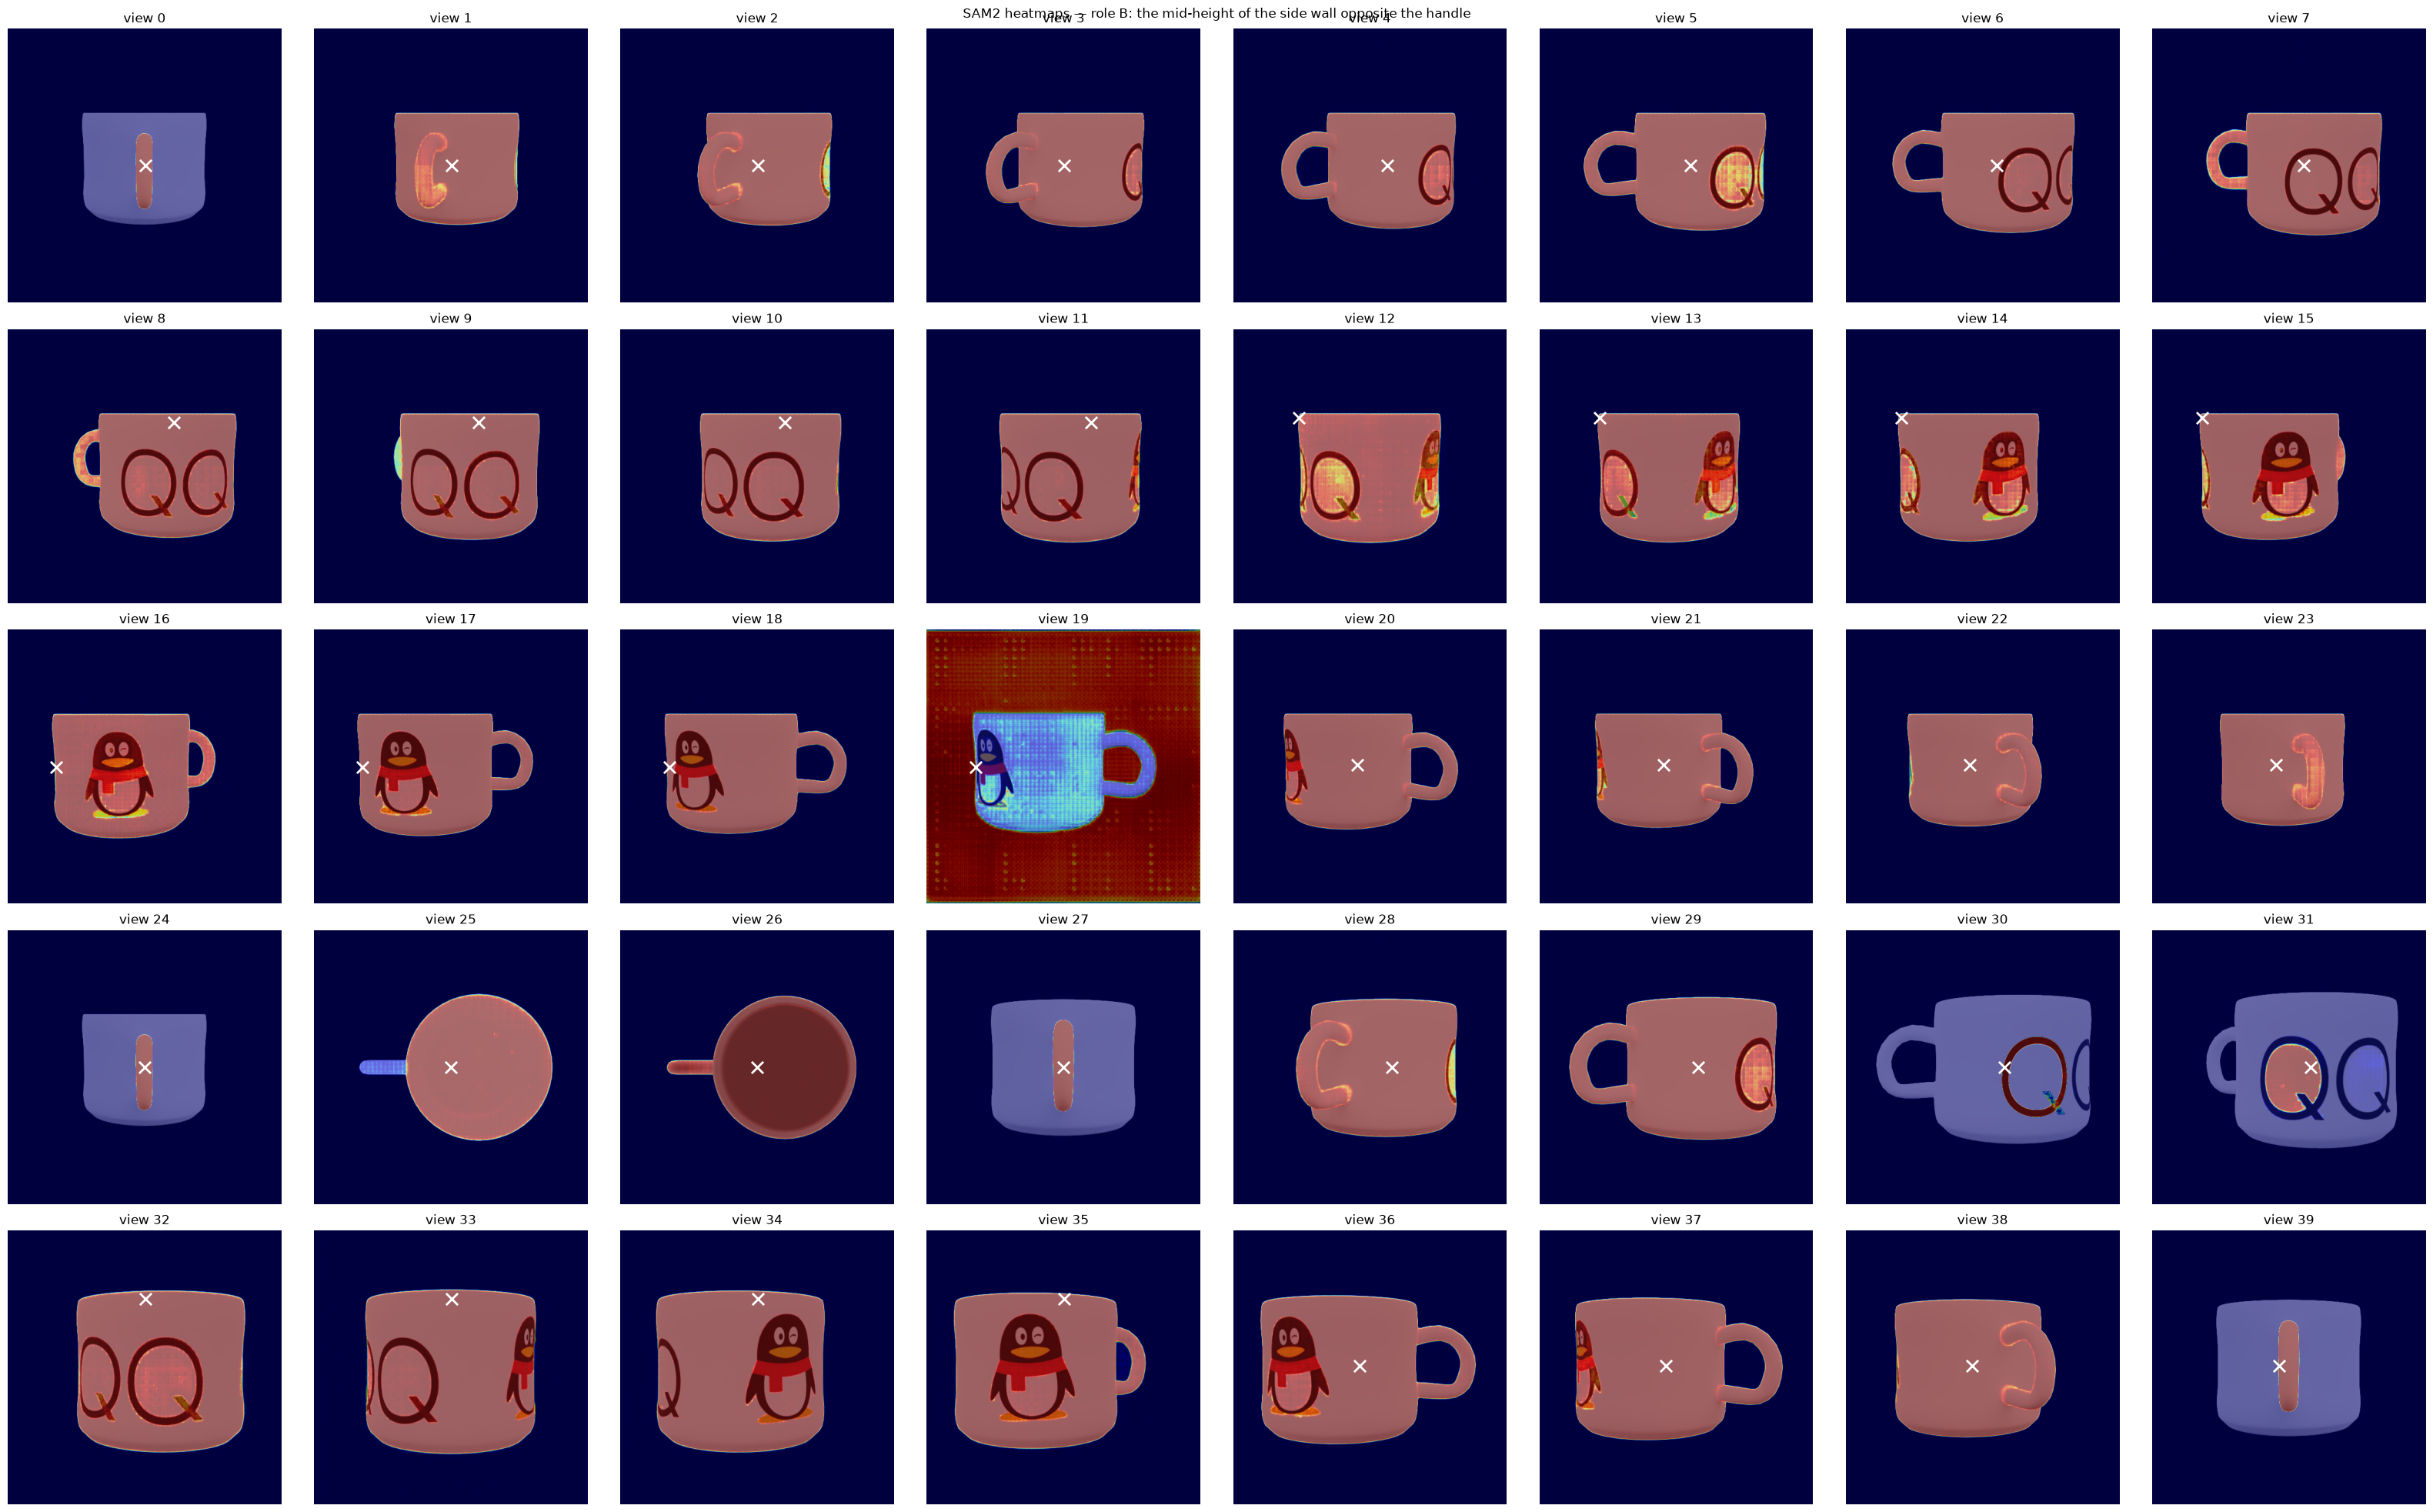

In [8]:
def show_heatmaps_on_views(pts_per_view, heatmaps, title, n=6):
    have = [i for i, p in enumerate(pts_per_view) if len(p) > 0][:n]
    if not have: print("no masks to show"); return
    cols = min(8, len(have)); rows = (len(have)+cols-1)//cols
    fig, ax = plt.subplots(rows, cols, figsize=(4*cols, 4*rows)); ax = np.atleast_1d(ax).ravel()
    for k, vi in enumerate(have):
        ax[k].imshow(view_images_np[vi])
        ax[k].imshow(heatmaps[vi], cmap="jet", alpha=0.5, vmin=0, vmax=1)
        for (x, y) in pts_per_view[vi]:
            ax[k].scatter([x], [y], s=120, marker="x", c="white", linewidths=2)
        ax[k].set_title(f"view {vi}"); ax[k].axis("off")
    for k in range(len(have), len(ax)): ax[k].axis("off")
    fig.suptitle(title); plt.tight_layout(); plt.show()

show_heatmaps_on_views(ptsA, hmA, f"SAM2 heatmaps — role A: {roleA['contact_region']}", n=NUM_VIEWS)
show_heatmaps_on_views(ptsB, hmB, f"SAM2 heatmaps — role B: {roleB['contact_region']}", n=NUM_VIEWS)

**Verify voting** — per-view masks fuse into a 3D heatmap on the affogato canvas (each role's region lights up: A, then B).

In [9]:
show_cloud(xyz, scoreA, f"Role A affordance: {roleA['role']} @ {roleA['contact_region']}",
           cmin=0, cmax=max(0.2, float(scoreA.max())), colorscale="Jet", colorbar=True).show()

In [10]:
show_cloud(xyz, scoreB, f"Role B affordance: {roleB['role']} @ {roleB['contact_region']}",
           cmin=0, cmax=max(0.2, float(scoreB.max())), colorscale="Jet", colorbar=True).show()

## 5 · The bimanual pair — both hands together
Show both coordinated regions on the canvas: this is the
two-region affordance the dataset is meant to produce.

In [11]:
# --- bimanual color scheme: role A = orange, role B = tiffany green ---
ORANGE,  TIFFANY  = "#F28E2B", "#0ABAB5"                # solid hues for the labels
ORANGE_SCALE  = [[0.0, "#FBDDB6"], [1.0, ORANGE]]       # light tint -> orange   (role A)
TIFFANY_SCALE = [[0.0, "#BFE9E6"], [1.0, TIFFANY]]      # light tint -> tiffany  (role B)

def two_role_fig(xyz, sA, sB, labelA, labelB, task_query, thr=0.15):
    s = slice(None, None, max(1, len(xyz)//60000))
    fig = go.Figure()
    fig.add_trace(go.Scatter3d(x=xyz[s,0],y=xyz[s,1],z=xyz[s,2],mode="markers",
        marker=dict(size=1.2,color="lightgrey",opacity=0.25),name="object",hoverinfo="skip"))
    for sc, name, scale in [(sA,labelA,ORANGE_SCALE),(sB,labelB,TIFFANY_SCALE)]:
        m = sc[s] > thr
        fig.add_trace(go.Scatter3d(x=xyz[s][m,0],y=xyz[s][m,1],z=xyz[s][m,2],mode="markers",
            marker=dict(size=1.2,color=sc[s][m],colorscale=scale,cmin=thr,
                        cmax=max(thr+0.05,float(sc.max())),opacity=0.9),name=name))

    # title as a centered block with left-aligned lines (annotation: xanchor center -> block is centered,
    # align left -> lines sit flush-left under each other): task query (neutral) + each role tag, colored
    title = (f'<b>Task query:</b> "{task_query}"<br>'
             + f"<span style='color:{ORANGE}'>Role A - {labelA}</span><br>"
             + f"<span style='color:{TIFFANY}'>Role B - {labelB}</span>")
    fig.add_annotation(text=title, xref="paper", yref="paper",
                       x=0.5, xanchor="center", y=1.02, yanchor="bottom",
                       align="left", showarrow=False, font=dict(size=13))

    fig.update_layout(
        width=860, height=720, scene=dict(aspectmode="data"),
        margin=dict(l=0, r=0, t=100, b=0), showlegend=False)
    return fig

two_role_fig(xyz, scoreA, scoreB,
             f"{roleA['role']} @ {roleA['contact_region']}",
             f"{roleB['role']} @ {roleB['contact_region']}",
             query["query"]).show()

## 5.5 · Refine + partition → two disjoint regions
Molmo grounds each role independently, so a **symmetric co-lift** collapses onto one region and an
**asymmetric** grasp overlaps at part boundaries. The production chain first **refines** each voted
score (drop satellite components <10% of the main mass; 2 rounds of kNN smoothing), then
`sra.partition_two_roles` splits by three object-agnostic layers:
1. **text symmetry** (same target + opposite/other-side wording) → straight vertical cut through the
   region center along a canvas axis;
2. **text vertical** (same-target vertical terms, or both-sided opposing terms on body-level targets)
   → horizontal gravity cut at the anchor-height midpoint;
3. **evidence** — same target: vertical cut at the two score-anchor midpoint; different targets:
   per-point winner-take-all on the >0.15 overlap with per-role p99 normalization (sub-threshold
   scores survive, so ranking info is kept while the supports become disjoint).
A guarded post-prune then clears winner-take-all remnants. Compare against the raw figure above.

In [ ]:
# production chain: refine (satellite prune + kNN smooth) -> partition -> guarded post-prune
idxNN = sra.knn_indices(xyz)
refA, refB = sra.refine_scores(scoreA, idxNN), sra.refine_scores(scoreB, idxNN)
fA, fB = sra.partition_two_roles(refA, refB, roleA, roleB, xyz)
scoreA_p, scoreB_p = sra.prune_partitioned(fA, refA, idxNN), sra.prune_partitioned(fB, refB, idxNN)
two_role_fig(xyz, scoreA_p, scoreB_p,
             f"{roleA['role']} @ {roleA['contact_region']}",
             f"{roleB['role']} @ {roleB['contact_region']}",
             query["query"]).show()

## 6 · Reference — affogato GT affordance channels
Bonus sanity check: the affogato canvas ships 5 GT affordance channels (single-region, different
queries than ours). Render one to confirm the canvas + colormap behave, and to eyeball where GT puts
its region vs where our pipeline puts each role.

In [ ]:
print("affogato GT queries:")
for i, gq in enumerate(gt_queries): print(f"  [{i}] {gq}")
GT_IDX = 2   # 'Point to the rim where you would place a spoon.' (handle-lift is GT[1])
show_cloud(xyz, gt[:, GT_IDX], f"affogato GT[{GT_IDX}]: {gt_queries[GT_IDX]}",
           cmin=0, cmax=max(0.2, float(gt[:, GT_IDX].max())), colorscale="Viridis", colorbar=True).show()

## 7 · Notes / next steps
- Swap `QUERY_IDX` to ground other tasks (e.g. 1 = 'tilt the mug for pouring': rotate @ handle + hold @ base).
- `cfg` knobs to compare: `mask_select` (`best_iou` vs `smallest`), `depth_tolerance`, `num_views`.
- To batch every query + persist scores at scale, use the production runner
  `pipeline/stage2_v2.py` (molmo env) — the exact chain above (mixed+neg SAM prompts, voting,
  refine, partition v6, post-prune), Molmo2-8B pointing on vLLM, object-batched SAM2;
  §8 below browses its outputs.

## 8 · stage2_v2 results browser
**Production runner: `pipeline/stage2_v2.py`** — Molmo2-8B on vLLM (k=4 multi-image prompts) +
object-batched SAM2 with mixed+neg prompts; browsed `scoreA/scoreB` are the final
refined+partitioned+post-pruned disjoint heatmaps (`scoreA_raw/scoreB_raw` keep the raw votes);
runs in the **molmo** conda env -> `outputs/bimanual_grounding_v2`.
Heavy code: `single_region/molmo2_vllm/` (vLLM engine + official point parsing) and sra
(SAM2/voting/partition).

The browser below reviews SAVED results (`scores.npz` includes per-view points -> full overlay).

In [16]:
# --- results browser: self-contained; run any time ---
import os, json as _json
import numpy as _np
import matplotlib.pyplot as _plt

V2_ROOT = f"{DG}/outputs/bimanual_grounding_v2"   # stage2_v2 (Molmo2 vLLM) outputs

def list_results(root=V2_ROOT, limit=20):
    for oid in sorted(os.listdir(root))[:limit]:
        for q in sorted(os.listdir(os.path.join(root, oid))):
            m = os.path.join(root, oid, q, "meta.json")
            if os.path.exists(m):
                meta = _json.load(open(m))
                print(f"{oid[:8]}  {q:44} hitA={meta.get('hitA','?'):>2} hitB={meta.get('hitB','?'):>2} "
                      f"cov={meta.get('coverage',0):.2f}  {meta.get('seconds','?')}s")

def show_result(object_id, qdir_name=None, root=V2_ROOT, n_views=8):
    """Overlay grid (saved ptsA/ptsB) + 3D two-role plot for one saved query.
    object_id may be a PREFIX (e.g. the 8-char id printed by list_results)."""
    matches = [d for d in sorted(os.listdir(root)) if d.startswith(object_id)]
    assert matches, f"no result dir starts with {object_id!r}"
    obj_dir = os.path.join(root, matches[0])
    qdirs = sorted(os.listdir(obj_dir))
    qd = os.path.join(obj_dir, qdir_name or qdirs[0])
    print(f"[{matches[0]}] querydirs: {qdirs}")
    d = _np.load(os.path.join(qd, "scores.npz"), allow_pickle=True)
    meta = _json.load(open(os.path.join(qd, "meta.json"))) if os.path.exists(os.path.join(qd, "meta.json")) else {}
    print(f"{meta.get('object_name','')} | {meta.get('task','')} | roles: "
          + " / ".join(f"{r['role']}@{r['contact_region']}" for r in meta.get("roles", [])))

    if "ptsA" in d.files:            # render per-view overlays on demand
        rec = next(r for r in _json.load(open(f"{DG}/outputs/stage1_v2/stage1_part0.json"))
                   if r["object_id"] == matches[0])
        obj_root = "/".join(rec["views_used"][0].split("/")[:-2])
        import single_region.single_region_affordance as _sra
        _, imgs_np = _sra.load_view_images(obj_root, min(len(d["ptsA"]), 40))
        have = [v for v in range(len(imgs_np))
                if _np.isfinite(d["ptsA"][v, 0]) or _np.isfinite(d["ptsB"][v, 0])][:n_views]
        cols = min(4, max(1, len(have))); rows = (len(have) + cols - 1) // cols
        fig, ax = _plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
        ax = _np.atleast_1d(ax).ravel()
        for i, v in enumerate(have):
            ax[i].imshow(imgs_np[v]); ax[i].axis("off"); ax[i].set_title(f"view {v}", fontsize=9)
            if _np.isfinite(d["ptsA"][v, 0]): ax[i].scatter(*d["ptsA"][v], s=150, marker="x", c="#F28E2B", linewidths=3)
            if _np.isfinite(d["ptsB"][v, 0]): ax[i].scatter(*d["ptsB"][v], s=150, marker="+", c="#0ABAB5", linewidths=3)
        for i in range(len(have), len(ax)): ax[i].axis("off")
        fig.suptitle("role A = orange x · role B = teal +"); _plt.tight_layout(); _plt.show()

    two_role_fig(d["xyz"], d["scoreA"], d["scoreB"],
                 "role A (partitioned)", "role B (partitioned)", meta.get("query", "")).show()

list_results()

0321ff8d  q0_pick_up_the_nitro_box                     hitA=40 hitB=36 cov=1.00  10.6s
0321ff8d  q1_move_the_nitro_box                        hitA=36 hitB=40 cov=1.00  10.3s
0321ff8d  q2_tilt_the_nitro_box_to_dispense_contents   hitA=40 hitB=40 cov=1.00  10.7s
0321ff8d  q3_tilt_the_nitro_box_to_keep_the_top_openi  hitA=40 hitB=40 cov=1.00  10.9s
0565230f  q0_pick_up_the_cube                          hitA=40 hitB=38 cov=1.00  13.3s
06bf1edc  q0_pick_up_the_book                          hitA=40 hitB=40 cov=1.00  10.3s
06bf1edc  q1_flip_the_pages                            hitA=40 hitB=40 cov=1.00  10.2s
06bf1edc  q2_fan_the_pages                             hitA=24 hitB=39 cov=1.00  8.7s
06bf1edc  q3_open_the_book                             hitA=40 hitB=40 cov=1.00  10.2s
06bf1edc  q4_hold_the_book_for_reading                 hitA=40 hitB=40 cov=1.00  10.2s
0a5a26b6  q0_pick_up_the_fruit_basket_with_book        hitA=36 hitB=40 cov=1.00  9.5s
0a5a26b6  q1_remove_the_book_from_the_assembl

[0321ff8d6ac74a668dc8aaa1b6b7eadc] querydirs: ['q0_pick_up_the_nitro_box', 'q1_move_the_nitro_box', 'q2_tilt_the_nitro_box_to_dispense_contents', 'q3_tilt_the_nitro_box_to_keep_the_top_openi']
Nitro Box | pick up the Nitro Box | roles: lift@mid-height of one side wall / lift@mid-height of the opposite side wall


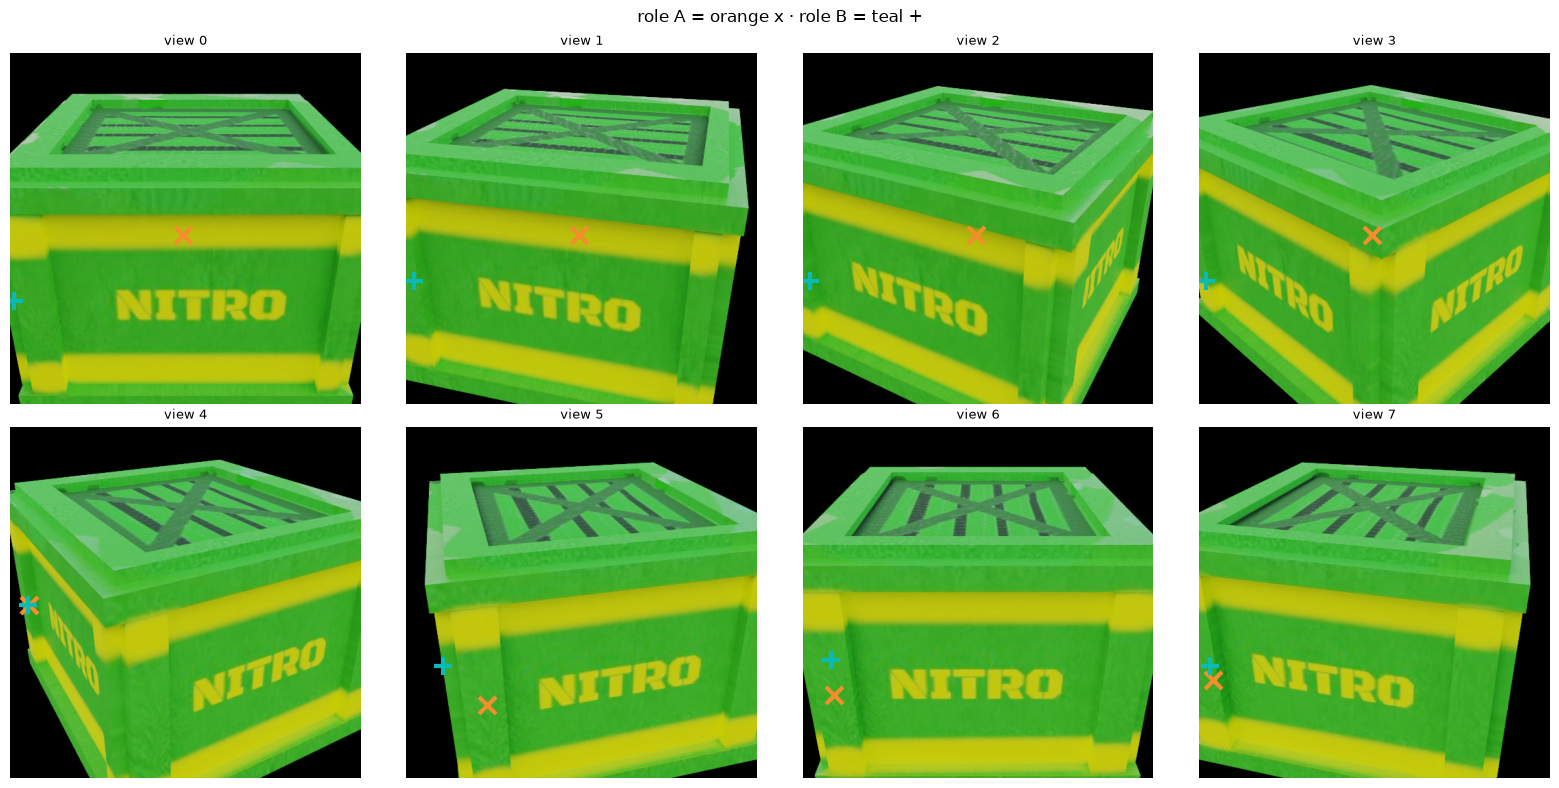

In [17]:
show_result("0321ff8d")